# Projekt Sieci Złożone: Analiza Społeczności na Różnych Poziomach Gęstości

Ten notatnik analizuje i porównuje wyniki dla całej sieci (SIMILAR) oraz trzech różnych progów filtrowania (LOW, MED, HIGH).

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from neo4j import GraphDatabase
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wykresów
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Konfiguracja połączenia
URI = os.environ.get("NEO4J_URI", "neo4j://neo4j:7687")
USER = "neo4j"
PASSWORD = "password"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return pd.DataFrame([r.values() for r in result], columns=result.keys())

## 1. Porównanie Podstawowych Statystyk Wszystkich Typów Relacji
Sprawdzamy statystyki dla pełnego grafu oraz przefiltrowanych wersji.

In [21]:
rel_types = ['SIMILAR', 'SIMILAR_LOW', 'SIMILAR_MED', 'SIMILAR_HIGH']
stats = []

for rel in rel_types:
    query = f"""
    MATCH (n:Game)
    WITH count(n) AS total_nodes
    OPTIONAL MATCH ()-[r:{rel}]->()
    WITH total_nodes, count(r) AS num_edges
    MATCH (n:Game)
    WHERE apoc.node.degree(n, '{rel}') > 0
    WITH total_nodes, num_edges, count(n) AS active_nodes, max(apoc.node.degree(n, '{rel}')) AS max_deg, avg(apoc.node.degree(n, '{rel}')) AS avg_deg
    RETURN '{rel}' AS rel_type, 
           total_nodes, 
           active_nodes, 
           total_nodes - active_nodes AS isolated_nodes,
           num_edges, 
           max_deg, 
           avg_deg, 
           CASE WHEN active_nodes > 1 THEN (num_edges * 2.0) / (active_nodes * (active_nodes - 1)) ELSE 0 END AS density_active
    """
    stats.append(run_query(query))

df_stats = pd.concat(stats).reset_index(drop=True)
display(df_stats)


,rel_type,total_nodes,active_nodes,isolated_nodes,num_edges,max_deg,avg_deg,density_active
0,SIMILAR,44023,30930,13093,132705593,29656,8581.027675,0.277443
1,SIMILAR_LOW,44023,17826,26197,40141140,17141,4503.662067,0.252660
2,SIMILAR_MED,44023,9621,34402,8541888,9336,1775.675709,0.184582
3,SIMILAR_HIGH,44023,3369,40654,407099,3270,241.673494,0.071756


## 2. Projekcja GDS i Algorytm Louvain dla poszczególnych progów
Odpalamy algorytm detekcji społeczności dla 3 przefiltrowanych sieci, zapisując wyniki do oddzielnych właściwości (community_id_low, med, high).

In [22]:
# Oczyszczanie ewentualnych starych projekcji
for suffix in ['LOW', 'MED', 'HIGH']:
    try:
        with driver.session() as session:
            session.run(f"CALL gds.graph.drop('games_{suffix}', false)")
    except: pass

louvain_results = []

for suffix in ['LOW', 'MED', 'HIGH']:
    rel_type = f"SIMILAR_{suffix}"
    prop_name = f"community_id_{suffix.lower()}"
    graph_name = f"games_{suffix}"
    
    print(f"Przetwarzanie {rel_type}...")
    
    # 1. Tworzenie projekcji natywnej (Nieskierowanej dla algorytmu Leiden)
    query_project = f"""
    CALL gds.graph.project(
      '{graph_name}',
      'Game',
      {{ {rel_type}: {{ orientation: 'UNDIRECTED', properties: 'jaccard' }} }}
    ) YIELD nodeCount, relationshipCount
    """
    run_query(query_project)
    
    # 2. Uruchamianie algorytmu Leiden (nowoczesnego następcy Louvain) z parametrem rozdzielczości
    query_louvain = f"""
    CALL gds.leiden.write('{graph_name}', {{
      relationshipWeightProperty: 'jaccard',
      writeProperty: '{prop_name}',
      gamma: 2.0
    }})
    YIELD communityCount, modularity
    RETURN '{rel_type}' AS rel_type, communityCount, modularity
    """
    louvain_results.append(run_query(query_louvain))

df_louvain = pd.concat(louvain_results).reset_index(drop=True)
display(df_louvain)
print("Społeczności zostały zapisane w Neo4j!")


Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)", position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'column': 1, 'offset': 0, 'line': 1}}> for query: "CALL gds.graph.drop('games_LOW', false)"
Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)", position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classi

Przetwarzanie SIMILAR_LOW...
Przetwarzanie SIMILAR_MED...
Przetwarzanie SIMILAR_HIGH...


,rel_type,communityCount,modularity
0,SIMILAR_LOW,28281,0.024760
1,SIMILAR_MED,35204,0.049259
2,SIMILAR_HIGH,40715,0.124985


Społeczności zostały zapisane w Neo4j!


## 3. Rozkład Wielkości Społeczności (Dla wszystkich progów)

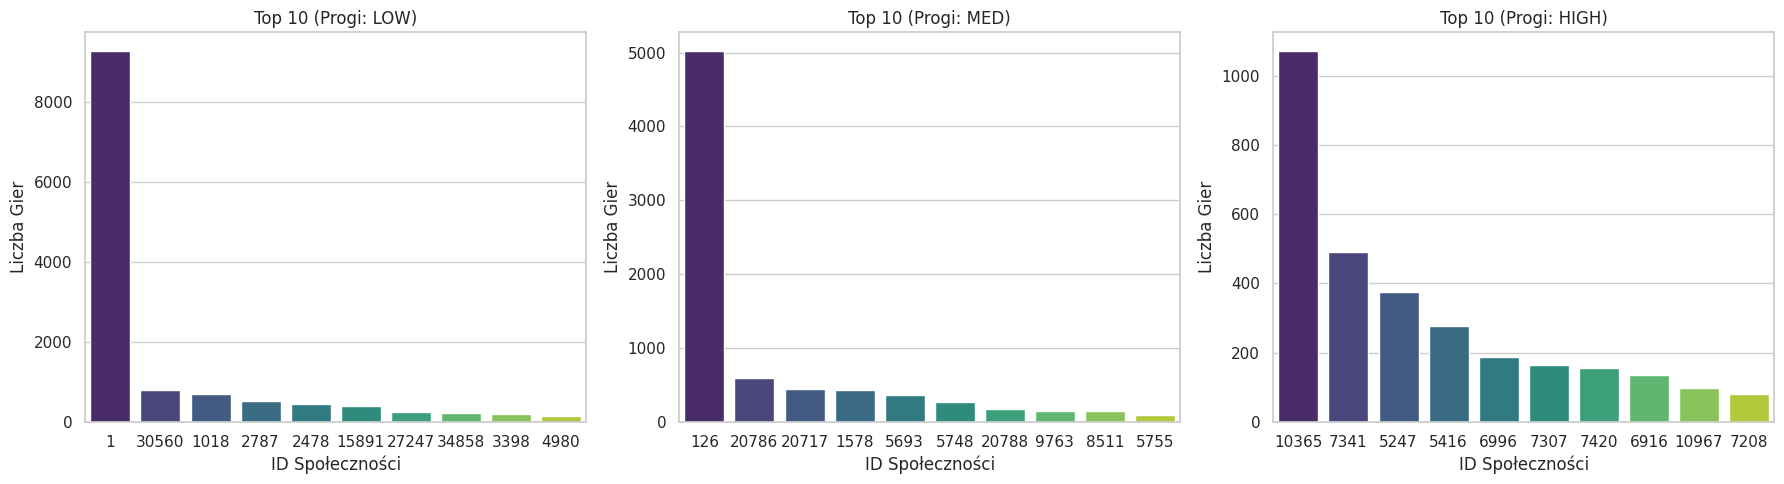

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, suffix in enumerate(['low', 'med', 'high']):
    prop = f"community_id_{suffix}"
    query = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, 'SIMILAR_' + toUpper('{suffix}')) > 0
    RETURN g.{prop} AS community, count(g) AS size
    ORDER BY size DESC
    LIMIT 10
    """
    df = run_query(query)
    sns.barplot(data=df, x='community', y='size', order=df['community'], palette='viridis', ax=axes[i])
    axes[i].set_title(f'Top 10 (Progi: {suffix.upper()})')
    axes[i].set_xlabel('ID Społeczności')
    axes[i].set_ylabel('Liczba Gier')

plt.tight_layout()
plt.show()


## 4. Dominujące Gatunki w Społecznościach (Skupmy się na średnim progu - MED)

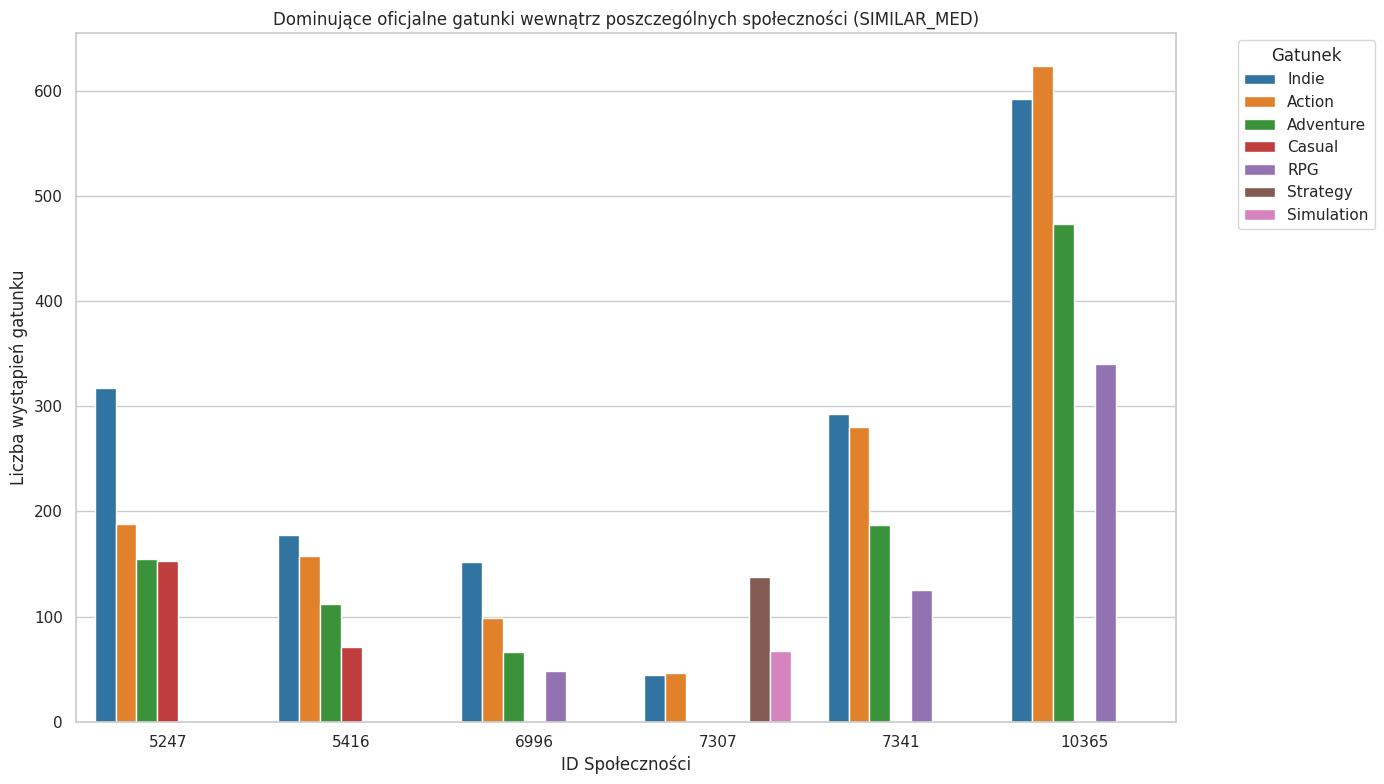

In [29]:
query_genres = """
MATCH (g:Game)
WHERE g.community_id_high IS NOT NULL AND apoc.node.degree(g, 'SIMILAR_HIGH') > 0
WITH g.community_id_high AS community, count(g) AS size
ORDER BY size DESC LIMIT 6

MATCH (g:Game)
WHERE g.community_id_high = community AND g.genres IS NOT NULL AND g.genres <> ''
UNWIND split(g.genres, '|') AS genre
WITH community, genre, count(*) AS count
ORDER BY count DESC
WITH community, collect({genre: genre, count: count})[0..4] AS top_genres
UNWIND top_genres AS tg
RETURN community, tg.genre AS genre, tg.count AS count
"""
df_genres = run_query(query_genres)

plt.figure(figsize=(14, 8))
sns.barplot(data=df_genres, x='community', y='count', hue='genre', palette='tab10')
plt.title('Dominujące oficjalne gatunki wewnątrz poszczególnych społeczności (SIMILAR_MED)')
plt.xlabel('ID Społeczności')
plt.ylabel('Liczba wystąpień gatunku')
plt.legend(title='Gatunek', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Homofilia Gatunkowa (Z wykorzystaniem krawędzi HIGH)
Używając najsilniejszych powiązań (SIMILAR_HIGH) badamy, które gatunki łączą się w hermetyczne grupy.

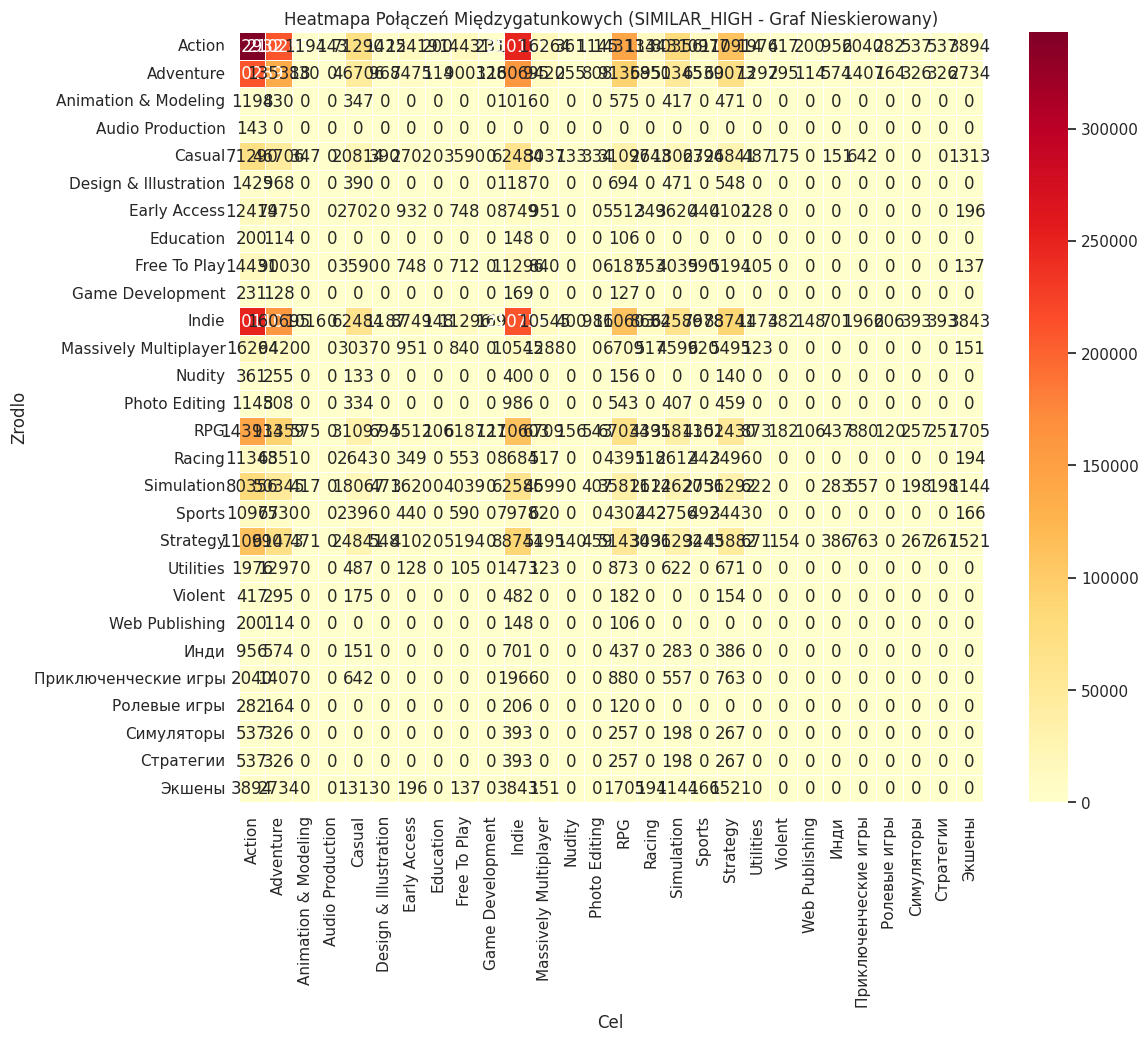

In [25]:
query_homophily = """
MATCH (n:Game)-[r:SIMILAR_HIGH]-(m:Game)
WHERE n.genres IS NOT NULL AND m.genres IS NOT NULL
UNWIND split(n.genres, '|') AS genre_n
UNWIND split(m.genres, '|') AS genre_m
WITH genre_n, genre_m, count(r) AS connections
WHERE connections > 100
RETURN genre_n AS Zrodlo, genre_m AS Cel, connections AS Sila_Polaczenia
ORDER BY Sila_Polaczenia DESC
LIMIT 400
"""
df_homophily = run_query(query_homophily)
pivot = df_homophily.pivot(index='Zrodlo', columns='Cel', values='Sila_Polaczenia').fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title('Heatmapa Połączeń Międzygatunkowych (SIMILAR_HIGH - Graf Nieskierowany)')
plt.show()
